# 1강 베이지안 통계의 개념: 증거로 믿음 갱신하기

이 노트북은 개념 강의와 풀이 예제를 먼저 보여준 뒤, 숫자와 맥락이 다른 문제를 직접 풀게 합니다. `대화 체크포인트`에서는 노트북을 잠시 멈추고 대화창에서 튜터의 질문에 답하세요.

학습 순서: **강의 → 풀이 예제 → 대화 확인 → 직접 입력 → 자동 점검 → 코드 변형 → 종합 평가**

## 베이지안 통계란 무엇인가

통계학에서는 언제나 관측한 것과 알고 싶은 것 사이에 간격이 있습니다. 예를 들어 구직자 10명의 자료는 관측할 수 있지만, 그 지역 전체 구직자의 실제 3개월 이내 재취업확률은 직접 볼 수 없습니다. 이처럼 **알 수 없는 값과 미래의 결과에 남아 있는 불확실성을 확률분포로 표현하는 방법**이 베이지안 통계입니다.

베이지안 추론은 다음 세 질문을 순서대로 묻습니다.

1. **데이터를 보기 전에는 무엇이 얼마나 가능하다고 생각하는가?**  
   이를 사전분포(prior distribution)로 표현합니다.
2. **각 모수값을 가정하면 현재 데이터는 얼마나 잘 설명되는가?**  
   데이터 생성모형과 우도(likelihood)로 표현합니다.
3. **실제 데이터를 본 뒤에는 믿음을 어떻게 바꾸어야 하는가?**  
   그 결과가 사후분포(posterior distribution)입니다.

이 관계를 한 줄로 쓰면 다음과 같습니다.

$$
\text{사후분포}
\propto
\text{우도}\times\text{사전분포}
$$

여기서 '믿음'은 근거 없이 원하는 답을 정한다는 뜻이 아닙니다. 어떤 사전 가정을 사용했는지 명시하고, 데이터가 그 가정을 얼마나 바꾸었는지 계산하며, 다른 사전분포를 사용했을 때 결론이 달라지는지도 점검해야 합니다. 즉 불확실성과 가정을 숨기지 않고 분석에 포함하는 것입니다.

### 빈도주의와 관점의 차이

- 빈도주의에서는 모수를 고정되어 있지만 알 수 없는 값으로 보고, 반복 표본에서 통계량이 어떻게 변하는지를 중심으로 추론합니다.
- 베이지안 통계에서는 모수에 관한 현재의 불확실성을 분포로 표현하고, 새로운 데이터가 들어올 때 그 분포를 갱신합니다.
- 두 접근 모두 데이터가 모수 아래에서 어떻게 생성되는지 나타내는 확률모형과 우도를 중요하게 사용합니다.

### 이번 강의의 전체 흐름

이번 강의에서는 먼저 몇 개의 가능한 성공확률만 놓고 믿음이 갱신되는 계산을 직접 확인합니다. 그다음 성공확률이 0과 1 사이의 모든 값을 가질 수 있도록 Beta 분포로 확장하고, 마지막에는 같은 구조를 재취업률 문제에 적용합니다.

```text
유한한 가설 비교
→ 사전분포 × 우도
→ 사후분포와 다음 관측 예측
→ 연속형 Beta 분포
→ 노동시장 사례
```

### 도입 대화 체크포인트

노트북을 잠시 멈추고 대화창에서 답하세요.

1. 자주 관측할 수 있는 데이터 하나와 직접 관측할 수 없는 모수 하나를 자신의 업무 또는 관심 분야에서 예로 들어보세요.
2. 데이터를 보기 전의 지식을 분석에 포함하는 것이 어떤 점에서는 유용하고, 어떤 점에서는 위험할 수 있을까요?

## 0. 개념 강의 - 사전분포, 우도, 사후분포

개념을 이해하기 위해 주로 동전 던지기 예제를 사용하지만, 약간 다르게 압정 던지기를 해봅시다.

압정을 던져서 뾰족한 부분이 위로 가면 성공, 아래로 가면 실패라고 합시다. 동전의 경우에는 앞면과 뒷면의 확률이 반반이라고 예상할 수 있지만, 압정의 경우에는 성공과 실패의 확률을 예상하기가 조금 더 어려울 겁니다.(그래서 압정 던지기 사례가 개념을 익히기에 더 좋습니다)

압정의 성공확률을 $p$라고 합시다. 가능한 가설이 `0.1`, `0.4`, `0.7`이고 사전확률이 각각 `0.2`, `0.5`, `0.3`이라고 가정합니다.

성공 한 번을 관측했을 때 이산형 우도는

$$
L(p;y)=P(Y=y\mid p)
$$

이며, 성공 한 번에 대한 우도는 각 가설의 성공확률과 같습니다.

$$
\text{posterior}\propto\text{likelihood}\times\text{prior}
$$

### 풀이 예제 0-A

다음 코드는 첫 예제를 완전히 풉니다. 실행하기 전에 어느 가설의 사후확률이 가장 높을지 예상하세요. 실행한 뒤에는 각 줄이 수식의 어느 부분인지 확인합니다.

In [1]:
# 배열 계산을 위해 NumPy를 불러옵니다.
import numpy as np

# 압정의 성공확률 p에 대해 세 가지 가설을 세웁니다.
# H1: p=0.1, H2: p=0.4, H3: p=0.7
demo_hypotheses = np.array([0.1, 0.4, 0.7])

# 데이터를 보기 전에 각 가설에 부여한 사전확률입니다.
# 세 값의 합은 1이어야 합니다.
demo_prior = np.array([0.2, 0.5, 0.3])

# 압정을 한 번 던져 '성공'을 관측했습니다.
# 가설 p 아래에서 성공할 확률은 p이므로 성공 한 번의 우도는 가설값과 같습니다.
demo_likelihood = demo_hypotheses

# 베이즈 갱신의 분자: 사전확률과 우도를 가설별로 곱합니다.
# 아직 합이 1이 아니므로 '정규화 전 사후 가중치'입니다.
demo_weights = demo_prior * demo_likelihood

# 모든 사후 가중치를 더해 정규화 상수(주변우도)를 구합니다.
demo_evidence = demo_weights.sum()

# 각 가중치를 정규화 상수로 나누어 합이 1인 사후분포를 만듭니다.
demo_posterior = demo_weights / demo_evidence

# zip으로 네 배열의 같은 위치에 있는 값들을 한 묶음씩 꺼냅니다.
# 각 반복에서 하나의 가설과 그 가설의 사전확률, 우도, 사후확률을 출력합니다.
for p, prior_value, likelihood_value, posterior_value in zip(
    demo_hypotheses, demo_prior, demo_likelihood, demo_posterior
):
    # :.1f는 소수점 첫째 자리, :.3f는 소수점 셋째 자리까지 표시합니다.
    print(
        f"p={p:.1f} | prior={prior_value:.3f} | "
        f"likelihood={likelihood_value:.3f} | posterior={posterior_value:.3f}"
    )

p=0.1 | prior=0.200 | likelihood=0.100 | posterior=0.047
p=0.4 | prior=0.500 | likelihood=0.400 | posterior=0.465
p=0.7 | prior=0.300 | likelihood=0.700 | posterior=0.488


### 대화 체크포인트 1

노트북을 잠시 멈추고 대화창에서 답하세요.

1. `demo_likelihood`의 합이 1이 아니어도 되는 이유는 무엇인가요?
2. `p=0.7`의 우도와 사후확률은 각각 어떤 질문에 답하나요?

튜터의 확인을 받은 뒤 다음 직접 입력 문제로 넘어갑니다.

## 1. 유한한 압정 가설 만들기

압정의 성공확률이 `0.2`, `0.5`, `0.8` 중 하나라고 단순화합니다. 세 가설의 사전확률은 모두 같습니다.

아래 빈 셀에 직접 입력하세요.

1. NumPy를 `np`라는 이름으로 불러옵니다.
2. `hypotheses`에 세 성공확률을 배열로 저장합니다.
3. `prior`에 세 사전확률을 배열로 저장합니다.
4. 두 배열을 출력합니다.

In [4]:
import numpy as np

# 세 성공확률을 배열로 저장
hypotheses = np.array([0.2, 0.5, 0.8])
# 세 사전확률을 배열로 저장
prior = np.array([1/3, 1/3, 1/3])

print("성공확률:",hypotheses)
print("사전확률:",prior)


성공확률: [0.2 0.5 0.8]
사전확률: [0.33333333 0.33333333 0.33333333]


In [5]:
# 자동 점검 1
import numpy as _np

_missing = [name for name in ["hypotheses", "prior"] if name not in globals()]
if _missing:
    print("아직 작성하지 않은 변수가 있습니다:", _missing)
else:
    assert _np.allclose(hypotheses, [0.2, 0.5, 0.8]), "hypotheses 값을 확인하세요."
    assert prior.shape == hypotheses.shape, "두 배열의 길이가 같아야 합니다."
    assert _np.all(prior >= 0), "사전확률은 음수가 될 수 없습니다."
    assert _np.isclose(prior.sum(), 1), "사전확률의 합은 1이어야 합니다."
    print("통과: 가설과 사전분포를 올바르게 만들었습니다.")

통과: 가설과 사전분포를 올바르게 만들었습니다.


## 2. 성공 한 번으로 갱신하기

압정을 한 번 던져 성공했습니다. 실행 전에 어느 가설의 믿음이 가장 커질지 예상해 적어보세요.

- 나의 예상:
- 그렇게 생각한 이유:

이산형 우도는 다음과 같습니다.

$$
L(p;y)=P(Y=y\mid p)
$$

성공 한 번의 우도는 각 가설의 성공확률과 같습니다. 아래 빈 셀에서 직접 계산하세요.

1. `likelihood`
2. `weights = prior * likelihood`
3. `evidence`: 가중치의 합
4. `posterior`: 가중치를 정규화한 배열

In [8]:
# 성공 한 번의 우도는 각 가설의 성공확률과 같다.
likelihood = hypotheses

# 가중치 = 사전분포 * 우도
weights = prior * likelihood

# 증거(주변우도)는 가중치의 합
evidence = weights.sum()

# 사후분포는 가중치를 정규화한 배열
posterior = weights / evidence

print("우도: ", likelihood)
print("가중치: ", weights)
print("증거(주변우도): ", evidence)
print("사후분포: ", posterior)

우도:  [0.2 0.5 0.8]
가중치:  [0.06666667 0.16666667 0.26666667]
증거(주변우도):  0.5
사후분포:  [0.13333333 0.33333333 0.53333333]


In [9]:
# 자동 점검 2
_required = ["likelihood", "weights", "evidence", "posterior"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    print("아직 작성하지 않은 변수가 있습니다:", _missing)
else:
    assert _np.allclose(likelihood, [0.2, 0.5, 0.8]), "성공 우도를 다시 생각해보세요."
    assert _np.isclose(evidence, 0.5), "정규화 상수를 확인하세요."
    assert _np.allclose(posterior, [2/15, 1/3, 8/15]), "사후분포 계산을 확인하세요."
    assert _np.isclose(posterior.sum(), 1), "사후확률의 합은 1이어야 합니다."
    print("통과: 사전 × 우도 → 정규화를 직접 구현했습니다.")

통과: 사전 × 우도 → 정규화를 직접 구현했습니다.


### 대화 체크포인트 2

대화창에서 다음 문장을 완성하세요.

- 모수 `p`는 ___입니다.
- 확률변수 `Y`는 ___입니다.
- 관측값 `y`는 ___입니다.
- 우도 `L(p; y)`는 ___를 고정하고 ___를 바꾸어 비교하는 함수입니다.

### 코드 변형 A

바로 위에서 작성한 코드를 복사하지 말고 다시 입력하세요.

- 이번 관측은 성공이 아니라 **실패 한 번**입니다.
- 사전분포는 직전에 얻은 `posterior`입니다.
- `failure_likelihood`, `second_weights`, `second_posterior`를 만드세요.

실행 전에 `p=0.2`와 `p=0.8` 중 어느 쪽의 믿음이 더 크게 줄어들지 예상하세요.

In [10]:
# 실패 우도 정의
failure_likelihood = 1 - hypotheses

# 가중치 계산하기
second_weights = posterior * failure_likelihood

# 증거(주변우도) 구하기
evidence = second_weights.sum()

# 사후분포 구하기
second_posterior = second_weights / evidence

print("실패 우도: ", failure_likelihood)
print("가중치: ", second_weights)
print("증거(주변우도): ", evidence)
print("사후분포: ", second_posterior)

실패 우도:  [0.8 0.5 0.2]
가중치:  [0.10666667 0.16666667 0.10666667]
증거(주변우도):  0.37999999999999995
사후분포:  [0.28070175 0.43859649 0.28070175]


In [11]:
# 자동 점검 3
_required = ["failure_likelihood", "second_weights", "second_posterior"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    print("아직 작성하지 않은 변수가 있습니다:", _missing)
else:
    assert _np.allclose(failure_likelihood, [0.8, 0.5, 0.2])
    assert _np.allclose(second_posterior, [16/57, 25/57, 16/57])
    print("통과: 이전 사후분포를 새 사전분포로 사용했습니다.")

통과: 이전 사후분포를 새 사전분포로 사용했습니다.


## 3. 임의의 성공·실패 자료를 처리하는 함수

성공 `h`회, 실패 `t`회의 우도는 다음에 비례합니다.

$$
L(p;y)\propto p^h(1-p)^t
$$

`bayes_update(hypotheses, prior, successes, failures)` 함수를 직접 작성하세요. 함수는 `(likelihood, evidence, posterior)`를 반환해야 합니다.

<details><summary>힌트 1</summary><code>hypotheses ** successes</code>로 성공 부분을 계산할 수 있습니다.</details>
<details><summary>힌트 2</summary><code>(1 - hypotheses) ** failures</code>를 곱합니다.</details>
<details><summary>힌트 3</summary>정규화 전 가중치의 합으로 각 가중치를 나눕니다.</details>

In [18]:
def bayes_update(hypotheses, prior, successes, failures):
    # 우도는 가설과 동일하다고 정의
    likelihood = hypotheses ** successes * (1-hypotheses) ** failures
    # 가중치 값 계산
    weights = prior * likelihood
    # 증거(주변우도) 구하기
    evidence = weights.sum()
    # 정규화된 사후가중치 구하기
    posterior = weights / evidence

    return likelihood, evidence, posterior
    

In [19]:
# 자동 점검 4
if "bayes_update" not in globals():
    print("bayes_update 함수를 먼저 작성하세요.")
else:
    _lk, _ev, _po = bayes_update(
        _np.array([0.2, 0.5, 0.8]),
        _np.array([1/3, 1/3, 1/3]),
        successes=4,
        failures=1,
    )
    assert _np.allclose(_lk, [0.00128, 0.03125, 0.08192])
    assert _np.allclose(_po, [0.011184, 0.273045, 0.715771], atol=1e-5)
    assert _np.isclose(_po.sum(), 1)
    print("통과: 일반화된 베이즈 갱신 함수를 구현했습니다.")

통과: 일반화된 베이즈 갱신 함수를 구현했습니다.


### 코드 변형 B - 사전분포의 힘

성공 4회, 실패 1회는 그대로 두고 사전분포만 `[0.8, 0.15, 0.05]`로 바꾸세요.

1. 실행 전에 가장 높은 사후확률을 가질 가설을 예상합니다.
2. `bayes_update`를 호출해 `strong_posterior`를 만듭니다.
3. 균등 사전분포 결과와 비교해 한 문장으로 설명합니다.

In [20]:
prior = np.array([0.8, 0.15, 0.05])

likelihood, evidence, strong_posterior = bayes_update(hypotheses, prior, 4, 1)

print("strong posterior: ", strong_posterior)

strong posterior:  [0.10440989 0.47795055 0.41763956]


In [21]:
# 자동 점검 5
if "strong_posterior" not in globals():
    print("strong_posterior를 먼저 계산하세요.")
else:
    assert _np.allclose(strong_posterior, [0.104410, 0.477951, 0.417639], atol=1e-5)
    print("통과: 같은 데이터에서도 사전분포가 결과를 바꾼다는 점을 확인했습니다.")

통과: 같은 데이터에서도 사전분포가 결과를 바꾼다는 점을 확인했습니다.


## 4. 연속형 모수와 Beta 분포

이제 성공확률이 세 값만 갖는다는 제한을 없앱니다.

$$
p\sim\operatorname{Beta}(\alpha,\beta)
$$

Beta 분포의 밀도는 다음에 비례합니다.

$$
p^{\alpha-1}(1-p)^{\beta-1}
$$

성공 $h$회, 실패 $t$회의 우도 $p^h(1-p)^t$를 곱하면 같은 형태가 유지되므로

$$
\operatorname{Beta}(\alpha,\beta)
\rightarrow
\operatorname{Beta}(\alpha+h,\beta+t)
$$

로 갱신됩니다. 이를 켤레성이라고 합니다.

### 풀이 예제 4-A

`Beta(2, 4)` 사전분포에서 성공 4회, 실패 1회를 관측합니다. 코드를 실행한 뒤 사전평균, 관측 성공비율, 사후평균의 위치를 비교하세요.

In [22]:
from scipy.stats import beta as beta_dist

demo_alpha_prior, demo_beta_prior = 2, 4
demo_successes, demo_failures = 4, 1
demo_alpha_post = demo_alpha_prior + demo_successes
demo_beta_post = demo_beta_prior + demo_failures

print("prior mean:", demo_alpha_prior / (demo_alpha_prior + demo_beta_prior))
print("observed rate:", demo_successes / (demo_successes + demo_failures))
print("posterior:", f"Beta({demo_alpha_post}, {demo_beta_post})")
print("posterior mean:", beta_dist(demo_alpha_post, demo_beta_post).mean())

prior mean: 0.3333333333333333
observed rate: 0.8
posterior: Beta(6, 5)
posterior mean: 0.5454545454545454


### 대화 체크포인트 3

왜 사후평균은 사전평균과 관측 성공비율 사이에 놓이나요? 데이터가 5개가 아니라 500개라면 어느 쪽에 더 가까워질지도 대화창에서 설명하세요.

### 직접 풀이 4-B

이제 숫자를 바꿉니다. 사전분포는 `Beta(3, 5)`, 관측자료는 성공 7회, 실패 3회입니다.

빈 셀에 직접 입력하세요.

1. `alpha_prior`, `beta_prior`, `successes`, `failures`
2. `alpha_post`, `beta_post`
3. `scipy.stats.beta`를 이용한 `posterior_mean`
4. 사전분포와 사후분포의 밀도 곡선

실행 전에는 곡선이 어느 방향으로 움직이고 폭이 어떻게 변할지 적어보세요.

In [24]:
# 사전분포 값 입력
alpha_prior = 3
beta_prior = 5

# 관측값 입력
successes = 7
failures = 3

# 사후분포 값 입력
alpha_post = alpha_prior + successes
beta_post = beta_prior + failures

from scipy.stats import beta as beta_dist

posterior_mean = beta_dist(alpha_post, beta_post).mean()
print("사후평균: ", posterior_mean)

사후평균:  0.5555555555555556


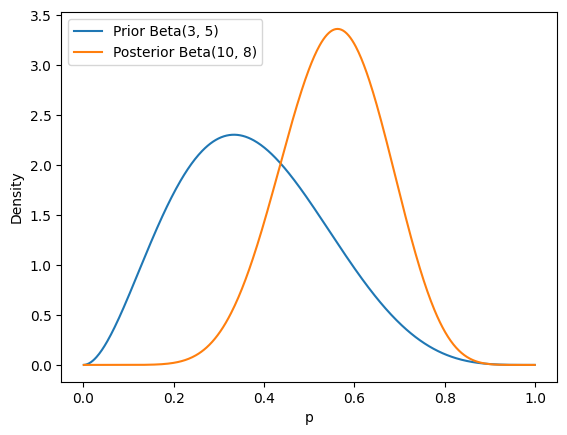

In [26]:
import matplotlib.pyplot as plt

# 0과 1 사이에서 밀도를 계산할 지점
p_grid = np.linspace(0.001, 0.999, 500)

# 각 지점에서 사전분포와 사후분포의 밀도 계산
prior_density = beta_dist(alpha_prior, beta_prior).pdf(p_grid)
posterior_density = beta_dist(alpha_post, beta_post).pdf(p_grid)

# 두 밀도 곡선 비교
plt.plot(p_grid, prior_density, label="Prior Beta(3, 5)")
plt.plot(p_grid, posterior_density, label="Posterior Beta(10, 8)")
plt.xlabel("p")
plt.ylabel("Density")
plt.legend()
plt.show()

In [25]:
# 자동 점검 6
_required = ["alpha_post", "beta_post", "posterior_mean"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    print("아직 작성하지 않은 변수가 있습니다:", _missing)
else:
    assert alpha_post == 10 and beta_post == 8
    assert _np.isclose(posterior_mean, 10/18)
    print("통과: Beta-Binomial 연속형 갱신을 구현했습니다.")

통과: Beta-Binomial 연속형 갱신을 구현했습니다.


## 5. 노동시장 문제로 전이하기

어떤 지역 구직자의 3개월 이내 재취업확률을 `theta`라고 합니다.

$$
\theta\sim\operatorname{Beta}(4,6),\qquad
Y\mid\theta\sim\operatorname{Binomial}(10,\theta),\qquad y=6
$$

빈 셀에서 다음을 직접 작성하세요.

1. 사후분포 모수 `labor_alpha_post`, `labor_beta_post`
2. 사후평균 `labor_posterior_mean`
3. 성공 수를 6에서 8로 바꾸어 `labor_posterior_mean_8`을 계산
4. 두 결과가 달라진 이유를 주석 한 줄로 설명

In [31]:
# 사전분포 값 입력
labor_alpha_prior = 4
labor_beta_prior = 6

# 관측값 입력
successes = 6
failures = 4

# 사후분포 값 입력
labor_alpha_post = labor_alpha_prior + successes
labor_beta_post = labor_beta_prior + failures

labor_posterior_mean = beta_dist(labor_alpha_post, labor_beta_post).mean()
print("사후평균_6: ", labor_posterior_mean)

# 관측값 입력
successes_8 = 8
failures_8 = 2

# 사후분포 값 입력
labor_alpha_post_8 = labor_alpha_prior + successes_8
labor_beta_post_8 = labor_beta_prior + failures_8

labor_posterior_mean_8 = beta_dist(labor_alpha_post_8, labor_beta_post_8).mean()
print("사후평균_8: ", labor_posterior_mean_8)

사후평균_6:  0.5
사후평균_8:  0.6


In [32]:
# 자동 점검 7
_required = ["labor_alpha_post", "labor_beta_post", "labor_posterior_mean", "labor_posterior_mean_8"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    print("아직 작성하지 않은 변수가 있습니다:", _missing)
else:
    assert labor_alpha_post == 10 and labor_beta_post == 10
    assert _np.isclose(labor_posterior_mean, 0.5)
    assert _np.isclose(labor_posterior_mean_8, 0.6)
    print("통과: 같은 구조를 노동시장 문제에 적용하고 데이터를 변형했습니다.")

통과: 같은 구조를 노동시장 문제에 적용하고 데이터를 변형했습니다.


## 6. 종합 평가

여기부터는 강의 내용을 보지 않고 풉니다. 객관식과 주관식은 대화창에서 튜터가 한 문제씩 묻습니다. 한꺼번에 정답을 확인하지 않습니다.

### 6.1 개념 확인 객관식

**문제 1.** 우도 $L(\theta;y)$가 직접 답하는 질문은 무엇인가요?

A. 데이터를 보았을 때 모수가 특정 값일 확률  
B. 모수가 특정 값일 때 현재 데이터가 관측될 확률 또는 밀도  
C. 사전분포가 참일 확률  
D. 다음 데이터가 현재 데이터와 같을 확률

**문제 2.** $Y\mid\theta\sim\operatorname{Binomial}(10,\theta)$이고 실제 성공자가 6명이면 올바른 설명은 무엇인가요?

A. $Y=10$, $y=\theta$  
B. $Y=6$, $y=10$  
C. $Y$는 성공자 수라는 확률변수이고 $y=6$  
D. $\theta=10$

**문제 3.** $\theta\sim\operatorname{Beta}(3,7)$에서 성공 8회, 실패 2회를 관측한 사후분포는 무엇인가요?

A. `Beta(8, 2)`  
B. `Beta(11, 9)`  
C. `Beta(5, 5)`  
D. `Beta(24, 14)`

**문제 4.** 성공비율이 같은 두 데이터셋 중 표본 수가 더 큰 자료가 일반적으로 만드는 변화는 무엇인가요?

A. 사후분포가 반드시 1로 이동한다.  
B. 사후분포가 대체로 더 좁아진다.  
C. 사전분포의 평균이 바뀐다.  
D. 우도의 합이 반드시 1이 된다.

**문제 5.** 실제 성공확률이 0.65지만 모형이 `0.2`, `0.5`, `0.8`만 허용할 때 데이터가 매우 많아지면 어떻게 되나요?

A. 모형이 자동으로 0.65를 새 후보로 만든다.  
B. 세 후보가 계속 같은 확률을 갖는다.  
C. 허용된 후보 중 데이터를 가장 잘 설명하는 값에 집중한다.  
D. 사후분포를 계산할 수 없다.

### 6.2 개념 확인 주관식

대화창에서 한 문제씩 답하세요.

1. `P(Y=y | theta)`와 `P(theta | Y=y)`의 차이를 압정 사례로 설명하세요.
2. 우도 곡선의 꼭대기와 사후분포의 꼭대기가 달라질 수 있는 이유를 설명하세요.
3. 연속형 모수에서 `P(theta=0.5)=0`일 수 있는데도 0.5 부근을 더 그럴듯하다고 표현할 수 있는 이유는 무엇인가요?
4. 재취업률 분석에서 `theta`, `Y`, `y`, `n`을 각각 정의하고 우도식을 작성하세요.

### 6.3 프로그래밍 평가 1 - Beta-Binomial 함수

앞에서 작성한 코드를 보지 않고 다음 함수를 새로 작성하세요.

```text
beta_update(alpha_prior, beta_prior, successes, failures)
```

반환값은 `(alpha_post, beta_post, posterior_mean)` 튜플이어야 합니다. 숫자를 코드 안에 고정하지 마세요.

In [ ]:
# 종합평가 자동 점검 1
if "beta_update" not in globals():
    print("beta_update 함수를 먼저 작성하세요.")
else:
    _case1 = beta_update(4, 6, 6, 4)
    _case2 = beta_update(2, 4, 40, 10)
    _case3 = beta_update(1, 1, 0, 5)
    assert _case1[:2] == (10, 10) and _np.isclose(_case1[2], 0.5)
    assert _case2[:2] == (42, 14) and _np.isclose(_case2[2], 0.75)
    assert _case3[:2] == (1, 6) and _np.isclose(_case3[2], 1/7)
    print("종합평가 통과: 새로운 입력에서도 Beta-Binomial 함수가 동작합니다.")

### 6.4 프로그래밍 평가 2 - 사전분포 민감도

성공 8회, 실패 2회에 대해 다음 세 사전분포의 사후분포를 비교하는 코드를 직접 작성하세요.

- `Beta(1, 1)`
- `Beta(2, 8)`
- `Beta(20, 80)`

요구사항:

1. 방금 작성한 `beta_update` 함수를 재사용합니다.
2. 세 사후평균을 표 형태로 출력합니다.
3. 사전분포와 사후분포 밀도를 한 그래프에 그립니다.
4. 같은 데이터인데 결과가 다른 이유를 코드 주석과 대화창에서 설명합니다.

### 6.5 프로그래밍 평가 3 - 노동시장 변형 문제

A 지역과 B 지역의 3개월 이내 재취업 자료를 비교하세요.

```text
공통 사전분포: Beta(3, 7)
A 지역: 20명 중 12명 재취업
B 지역: 200명 중 120명 재취업
```

두 지역은 관측 재취업률이 같지만 표본 수가 다릅니다.

1. 두 사후분포를 계산하고 한 그래프에 그립니다.
2. 사후평균과 95% 크레디블 구간을 출력합니다.
3. 위치와 폭의 차이를 대화창에서 설명합니다.

## 7. 강의 종료 기록

종합평가를 마친 뒤 다음을 `RESULT.md`에 기록합니다.

1. 모수 `theta`, 확률변수 `Y`, 관측값 `y`의 차이
2. 우도와 사후분포의 조건 방향 차이
3. 사전분포가 결과에 영향을 주는 경우
4. 데이터가 늘면 사후분포의 위치와 폭이 어떻게 결정되는지
5. 객관식·주관식 답변과 교정 과정
6. 프로그래밍 평가 실행 결과와 코드 변형 설명

정답뿐 아니라 처음의 예상, 막힌 지점, 수정한 설명을 함께 남깁니다.